In [12]:
# connect to t4 gpu
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [13]:


from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Generate batches of tensor image data with real-time data augmentation.
datagen = ImageDataGenerator(rescale=1./255,
                                                     rotation_range=30,
                                                    horizontal_flip=True)

training_set=datagen.flow_from_directory('/content/drive/MyDrive/datafiles/SmallDataset/training_set',
                                        target_size=(64,64),
                                        batch_size=20,
                                        class_mode = 'binary')
test_set=datagen.flow_from_directory('/content/drive/MyDrive/datafiles/SmallDataset/test_set',
                                    target_size=(64,64),
                                    batch_size=20,
                                    class_mode = 'binary')
# class_mode='categorical' if you have more than 2 classses

Found 200 images belonging to 2 classes.
Found 60 images belonging to 2 classes.


In [15]:
model = Sequential()
model.add(Input((64,64,3)))
model.add(Conv2D(32,(3,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128, (3,3)))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

In [17]:
model.fit(training_set, epochs=30, validation_data=test_set)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.5111 - loss: 0.8405 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.5317 - loss: 0.6924 - val_accuracy: 0.6500 - val_loss: 0.6767
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.5139 - loss: 0.6893 - val_accuracy: 0.5667 - val_loss: 0.6753
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5697 - loss: 0.6824 - val_accuracy: 0.5000 - val_loss: 0.6831
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4909 - loss: 0.7000 - val_accuracy: 0.6500 - val_loss: 0.6718
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5795 - loss: 0.6655 - val_accuracy: 0.5000 - val_loss: 0.7233
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.5546 - loss: 0.6875 - val_accuracy: 0.5667 - val_loss: 0.6793
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.6709 - loss: 0.6451 - val_accuracy: 0.65

In [18]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

(64, 64, 3)
(1, 64, 64, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step


array([[0.]], dtype=float32)

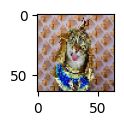

In [19]:
img = image.load_img('/content/drive/MyDrive/datafiles/SmallDataset/single_prediction/c4.jpg'
                    ,target_size = (64,64))
plt.figure(figsize=(1,1))
plt.imshow(img);
test_img = np.asarray(img)
print(test_img.shape)
# reshape to add 1 row
test_img = test_img.reshape(1,64,64,3)
print(test_img.shape)
model.predict(test_img)

In [20]:
from tensorflow.keras.models import save_model

In [21]:
save_model(model, 'mycatsdogs.h5')

(64, 64, 3)
(1, 64, 64, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[1.]], dtype=float32)

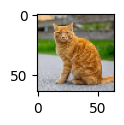

In [22]:
img = image.load_img('/content/download.jpg'
                    ,target_size = (64,64))
plt.figure(figsize=(1,1))
plt.imshow(img);
test_img = np.asarray(img)
print(test_img.shape)
# reshape to add 1 row
test_img = test_img.reshape(1,64,64,3)
print(test_img.shape)
model.predict(test_img)

In [22]:
# 0 means dog, 1 means Cat